In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_2104.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_2771.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/20200313_165937.jpg
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_3167.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_2760.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_2844.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_20200107_113948993.jpg
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_2765.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_2711.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset/Metal/IMG_3114.JPG
/kaggle/input/waste-classification-dataset/Waste_Classification_Datas

In [17]:
!ls /kaggle/input/waste-classification-dataset


Waste_Classification_Dataset


In [18]:
dataset_path = "/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset"
import os

categories = os.listdir(dataset_path)
print("Categories:", categories)

Categories: ['Metal', 'Paper', 'Miscellaneous', 'Plastic']


## SPLITTING DATA

In [19]:
import os
import shutil
import random
from tqdm import tqdm  # progress bar


random.seed(42)

dataset_path = '/kaggle/input/waste-classification-dataset/Waste_Classification_Dataset'

# Nơi lưu dataset sau khi chia
base_dir = '/kaggle/working/waste_dataset_split'

# Tên các class
classes = ['Metal', 'Plastic', 'Miscellaneous', 'Paper']

# Kiểm tra và tạo cấu trúc thư mục nếu chưa có
if not os.path.exists(base_dir):
    for split in ['train', 'val', 'test']:
        for class_name in classes:
            os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

    # Đếm số ảnh trong mỗi class
    class_counts = {}
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        class_counts[class_name] = len(image_files)

    # Kiểm tra nhanh
    print("Số ảnh trong mỗi class:")
    for c, n in class_counts.items():
        print(f"{c:15s}: {n}")

    # Tỷ lệ chia dữ liệu
    train_ratio, val_ratio, test_ratio = 0.8, 0.1, 0.1

    print("\nSplitting dataset...")
    split_summary = {}

    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        random.shuffle(all_images)

        total = len(all_images)
        train_size = int(total * train_ratio)
        val_size = int(total * val_ratio)
        test_size = total - train_size - val_size

        train_images = all_images[:train_size]
        val_images = all_images[train_size:train_size + val_size]
        test_images = all_images[train_size + val_size:]

        # Copy ảnh sang thư mục mới
        for split_name, images in [('train', train_images), ('val', val_images), ('test', test_images)]:
            for img in tqdm(images, desc=f"Copying {class_name} {split_name}", total=len(images)):
                src = os.path.join(class_path, img)
                dst = os.path.join(base_dir, split_name, class_name, img)
                shutil.copy2(src, dst)

        split_summary[class_name] = {
            'train': len(train_images),
            'val': len(val_images),
            'test': len(test_images)
        }

    print("\nSplit dataset done!")
    for key, value in split_summary.items():
        print(f"{key:15s}: Train={value['train']:4d}, Val={value['val']:3d}, Test={value['test']:3d}")
else:
    print(" Split folder already exists, skipping dataset splitting to save time!")


 Split folder already exists, skipping dataset splitting to save time!


In [20]:
# Kiểm tra nội dung /kaggle/working/ (nơi thường lưu kết quả split)
print("Contents of /kaggle/working/:")
!ls /kaggle/working/

# Kiểm tra chi tiết nếu có thư mục dataset
for folder in os.listdir('/kaggle/working/'):
    folder_path = os.path.join('/kaggle/working/', folder)
    if os.path.isdir(folder_path):
        print(f"\nContents of {folder_path}:")
        !ls {folder_path}

Contents of /kaggle/working/:
artifacts  waste_dataset_split

Contents of /kaggle/working/artifacts:
baseline_best.keras

Contents of /kaggle/working/waste_dataset_split:
test  train  val

Contents of /kaggle/working/.virtual_documents:


In [3]:
# IMPORT LIBRARIES
import os, shutil, random, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [5]:
# CONFIG
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# (khuyến nghị nếu GPU hỗ trợ)
try:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
except Exception:
    pass
DST_DIR = Path("dataset")
IMG_SIZE = 224
BATCH_SIZE = 32
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)

In [1]:
import tensorflow as tf
import tensorflow.keras
tensorflow.keras.backend.clear_session()

In [23]:
# Clear session
import tensorflow as tf
import tensorflow.keras
tensorflow.keras.backend.clear_session()

dataset_path = '/kaggle/working/waste_dataset_split'
print("Available directories in dataset:", os.listdir(dataset_path))

train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')
test_dir = os.path.join(dataset_path, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.12,
    shear_range=8,                 # độ (degrees)
    zoom_range=0.12,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    channel_shift_range=15.0,
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 32
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# Lấy đúng thứ tự class từ train
class_names = list(train_gen.class_indices.keys())

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=class_names   # <-- KHÓA THỨ TỰ CLASS
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=class_names
)

print("Data generators ready! Total batches:", len(train_gen))
print("Class distribution in train_generator:", np.bincount(train_gen.classes))

# Sanity check: mapping phải giống hệt
assert train_gen.class_indices == val_gen.class_indices == test_gen.class_indices
print("Classes:", class_names)

Available directories in dataset: ['test', 'train', 'val']
Found 13023 images belonging to 4 classes.
Found 1626 images belonging to 4 classes.
Found 1632 images belonging to 4 classes.
Data generators ready! Total batches: 407
Class distribution in train_generator: [1826 3539 2213 5445]
Classes: ['Metal', 'Miscellaneous', 'Paper', 'Plastic']


## MODEL

In [8]:
# Build SimpleCNN (Keras)
def conv_block(x, c, k=3, s=1, p='same'):
    x = layers.Conv2D(c, k, strides=s, padding=p, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))
x = conv_block(inp, 32)
x = conv_block(x, 32, s=2)   # l1
x = conv_block(x, 64)
x = conv_block(x, 64, s=2)   # l2
x = conv_block(x, 128)
x = conv_block(x, 128, s=2)  # l3
x = conv_block(x, 256)       # extra
x = layers.Dropout(0.25)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)              # 128 -> 256
x = layers.BatchNormalization()(x)     # thêm BN
x = layers.ReLU()(x)
x = layers.Dropout(0.35)(x)            # 0.30 -> 0.35
out = layers.Dense(4, activation='softmax', dtype='float32')(x)
model = models.Model(inp, out)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 652,132 (2.49 MB)

 Trainable params: 650,212 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [25]:
EPOCHS = 50

# Dùng len(generator) để tránh hụt batch cuối
decay_steps = len(train_gen) * EPOCHS

initial_lr = 1e-5
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=decay_steps,
    alpha=0.03     # LR floor = 10% initial_lr, không rơi về 0
)

opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ],
)

CKPT_DIR = Path("artifacts"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = str(CKPT_DIR / "baseline_best.keras")   # định dạng mới

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy', mode='max',
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', mode='max',
        patience=7, restore_best_weights=True
    ),
]

In [26]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.4752 - loss: 1.2369 - precision: 0.5401 - recall: 0.3425
Epoch 1: val_accuracy improved from -inf to 0.39606, saving model to artifacts/baseline_best.keras
407/407 ━━━━━━━━━━━━━━━━━━━━ 181s 414ms/step - accuracy: 0.4753 - loss: 1.2367 - precision: 0.5402 - recall: 0.3426 - val_accuracy: 0.3961 - val_loss: 1.4365 - val_precision: 0.3804 - val_recall: 0.1193
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6045 - loss: 1.0149 - precision: 0.6639 - recall: 0.4866
Epoch 2: val_accuracy improved from 0.39606 to 0.70541, saving model to artifacts/baseline_best.keras
407/407 ━━━━━━━━━━━━━━━━━━━━ 163s 401ms/step - accuracy: 0.6045 - loss: 1.0149 - precision: 0.6639 - recall: 0.4866 - val_accuracy: 0.7054 - val_loss: 0.8732 - val_precision: 0.8077 - val_recall: 0.5141
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6387 - loss: 0.9488 - precision: 0.7101 - recall: 0.5307
Epoch 3: val_accur

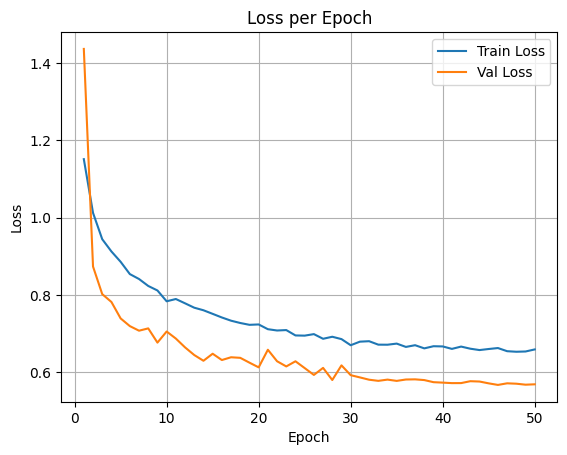

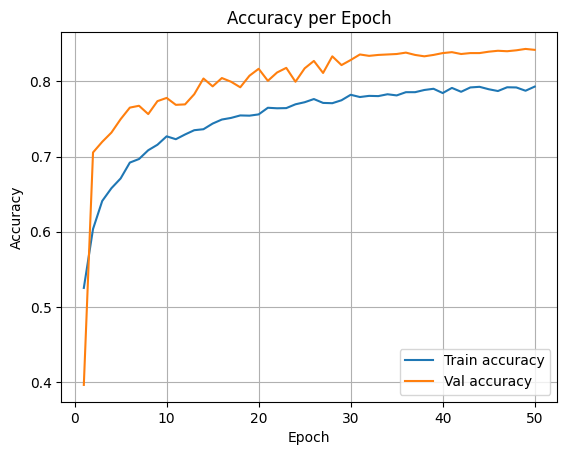

In [27]:
# === Training Curves: Loss & Accuracy per Epoch ===
import matplotlib.pyplot as plt

# Lấy log từ History object
hist = history.history

# Tự động dò tên metric accuracy phù hợp
acc_key = None
for k in hist.keys():
    if k in ("accuracy", "categorical_accuracy", "sparse_categorical_accuracy", "acc"):
        acc_key = k
        break

val_acc_key = f"val_{acc_key}" if acc_key and f"val_{acc_key}" in hist else None

epochs = range(1, len(hist["loss"]) + 1)

# ---- Loss curve ----
plt.figure()
plt.plot(epochs, hist["loss"], label="Train Loss")
if "val_loss" in hist:
    plt.plot(epochs, hist["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# ---- Accuracy curve ----
plt.figure()
if acc_key:
    plt.plot(epochs, hist[acc_key], label=f"Train {acc_key}")
if val_acc_key:
    plt.plot(epochs, hist[val_acc_key], label=f"Val {acc_key}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [28]:
print(model.evaluate(val_gen, verbose=0))
print(model.evaluate(val_gen, verbose=0))  # 2 lần nên gần giống nhau


[0.5674085021018982, 0.8431734442710876, 0.8774811625480652, 0.7884379029273987]
[0.5674085021018982, 0.8431734442710876, 0.8774811625480652, 0.7884379029273987]


Evaluate on test:
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8352 - loss: 0.5523 - precision: 0.9041 - recall: 0.7816
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step

F1-macro: 0.8579217958173718

Classification report:
               precision    recall  f1-score   support

        Metal     0.7960    0.8690    0.8309       229
Miscellaneous     0.8810    0.8352    0.8575       443
        Paper     0.8884    0.8022    0.8431       278
      Plastic     0.8819    0.9194    0.9002       682

     accuracy                         0.8695      1632
    macro avg     0.8618    0.8564    0.8579      1632
 weighted avg     0.8707    0.8695    0.8692      1632


Confusion matrix:
 [[199  17   2  11]
 [ 21 370  17  35]
 [  5  12 223  38]
 [ 25  21   9 627]]


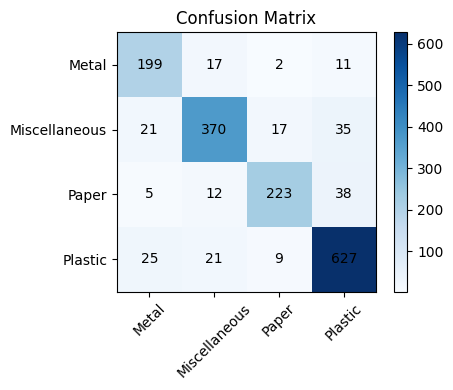

In [29]:
# Evaluate on test & full report
best_model = tf.keras.models.load_model(CKPT_PATH)

print("Evaluate on test:")
best_model.evaluate(test_gen, verbose=1)

y_prob = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

print("\nF1-macro:", f1_score(y_true, y_pred, average='macro'))
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix:\n", cm)

# (tuỳ chọn) visualize confusion matrix đẹp
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix"); plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout(); plt.show()
